# Pontifícia Universidade Católica do Paraná
## Disciplina: Técnicas de Machine Learning
### Somativa 1
### Aluno: Vanderlei Sutil de Córdova

In [1]:
import pandas as pd # biblioteca usada para manipulação de dataframes
import numpy as np # manipulação de tabelas
import matplotlib.cm as mcm # biblioteca para mostrar gráficos (espeficamente uma parte para cores)
import matplotlib.pyplot as plt # biblioteca para mostrar gráficos (espeficamente uma parte para criar gráficos)
import seaborn as sns # outra biblioteca para mostrar gráficos (ela é especificamente boa para alguns tipos de gráficos, como mapas de calor)

from ydata_profiling import ProfileReport # Biblioteca para análise exploratória dos dados
#from sklearn.preprocessing import LabelEncoder # Biblioteca para normalização dos dados
from sklearn.feature_selection import *
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import * # importando todas as funções específicas para a extração de atributos do scikit-learn
from sklearn.cluster import * # importando todas as funções específicas para o agrupamento

from sklearn.model_selection import train_test_split # Importação da biblioteca para divisão do dataset
from sklearn.ensemble import RandomForestClassifier # Biblioteca para treinamento dos dados


In [2]:
%matplotlib inline

## Escolhi o dataset cs:go contendo diversos dados das partidas, a idéia é prever se o vencedor final da partida será CT ou T.

In [3]:
# Carregamento do dataset e remoção dos dados duplicados
df = pd.read_excel('csgo_round_snapshots.xlsx') 
df = df.drop_duplicates() 
df.head()


,time_left,ct_score,t_score,map,ct_health,t_health,ct_money,t_money,ct_helmets,t_helmets,...,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner
0,175.00,0,0,de_dust2,500,500,4000,4000,0,0,...,0,0,0,0,0,0,0,0,0,CT
1,156.03,0,0,de_dust2,500,500,600,650,0,0,...,0,0,2,0,0,0,0,0,0,CT
2,96.03,0,0,de_dust2,391,400,750,500,0,0,...,0,0,2,0,0,0,0,0,0,CT
3,76.03,0,0,de_dust2,391,400,750,500,0,0,...,0,0,0,0,0,0,0,0,0,CT
4,174.97,1,0,de_dust2,500,500,18350,10750,0,0,...,0,0,0,0,0,0,0,0,0,CT


In [4]:
# Etapa da compreensão dos dados (Análise exploratória)
df.describe()
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 117445 entries, 0 to 122409
Data columns (total 94 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   time_left                     117445 non-null  float64
 1   ct_score                      117445 non-null  int64  
 2   t_score                       117445 non-null  int64  
 3   map                           117445 non-null  object 
 4   ct_health                     117445 non-null  int64  
 5   t_health                      117445 non-null  int64  
 6   ct_money                      117445 non-null  int64  
 7   t_money                       117445 non-null  int64  
 8   ct_helmets                    117445 non-null  int64  
 9   t_helmets                     117445 non-null  int64  
 10  ct_defuse_kits                117445 non-null  int64  
 11  ct_players_alive              117445 non-null  int64  
 12  t_players_alive               117445 non-null  in

In [5]:
# Para limpeza dos dados decidi iniciar por remover algumas colunas referentes as granadas por acreditar que não são relevantes para nossa análise

cols_grenade = 'grenade'
df = df.drop(df.columns[df.columns.str.contains(cols_grenade)], axis=1)
df.describe()

,time_left,ct_score,t_score,ct_health,t_health,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,...,ct_weapon_fiveseven,t_weapon_fiveseven,ct_weapon_usps,t_weapon_usps,ct_weapon_p250,t_weapon_p250,ct_weapon_p2000,t_weapon_p2000,ct_weapon_tec9,t_weapon_tec9
count,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000,...,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000,117445.000000
mean,94.646046,6.769722,6.828941,408.520286,398.656239,10000.571331,11492.553536,2.120082,2.868585,1.650202,...,0.063408,0.009707,3.124092,0.126468,0.244838,0.289940,0.170820,0.005075,0.008344,0.029316
std,53.223651,4.802211,4.832397,133.834178,141.394320,11308.837482,12245.960928,1.831710,1.976501,1.614365,...,0.292482,0.101793,1.588128,0.445495,0.540835,0.578565,0.421193,0.075923,0.096242,0.194612
min,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,54.910000,3.000000,3.000000,336.000000,309.000000,1300.000000,1650.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,94.890000,6.000000,6.000000,500.000000,500.000000,5900.000000,7650.000000,2.000000,3.000000,1.000000,...,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,114.960000,10.000000,11.000000,500.000000,500.000000,15000.000000,18350.000000,4.000000,5.000000,3.000000,...,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,175.000000,32.000000,33.000000,500.000000,600.000000,80000.000000,80000.000000,5.000000,5.000000,5.000000,...,5.000000,2.000000,10.000000,5.000000,5.000000,5.000000,3.000000,3.000000,2.000000,4.000000


In [6]:
# A fim de transformar as colunas que contenham textos como a coluna 'map' decidi usar o OneHotEncoder pois não existe uma relação de pesos nos mapas.

df_encoded_robust = pd.get_dummies(df, columns=['map'], drop_first=True, dtype=int) # dtype=int para ter 0s e 1s em vez de True/False
df_encoded_robust.head() # foram criadas novas colunas com valores booleanos como a map_de_cache

,time_left,ct_score,t_score,ct_health,t_health,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,...,ct_weapon_tec9,t_weapon_tec9,round_winner,map_de_dust2,map_de_inferno,map_de_mirage,map_de_nuke,map_de_overpass,map_de_train,map_de_vertigo
0,175.00,0,0,500,500,4000,4000,0,0,0,...,0,0,CT,1,0,0,0,0,0,0
1,156.03,0,0,500,500,600,650,0,0,1,...,0,0,CT,1,0,0,0,0,0,0
2,96.03,0,0,391,400,750,500,0,0,1,...,0,0,CT,1,0,0,0,0,0,0
3,76.03,0,0,391,400,750,500,0,0,1,...,0,0,CT,1,0,0,0,0,0,0
4,174.97,1,0,500,500,18350,10750,0,0,1,...,0,0,CT,1,0,0,0,0,0,0


In [7]:
# Usando o ProfileReport para identificação dos outliers
#profile = ProfileReport(df_encoded_robust)
# Salva o relatório em um arquivo HTML separado
#profile.to_file("meu_relatorio_csgo.html")

# Com base no relatório gerado foi possível identificar alguns alertas
## * Colunas constantes (Constant)

In [8]:
# Para tratamento das colunas constantes irei utilizar o VarianceThreshold
# Separando o target do dataset original
y = df_encoded_robust.round_winner
X = df_encoded_robust.drop(['round_winner'], axis=1)

selector = VarianceThreshold(threshold=0.0)
selector.fit(X)

# O método .get_support() retorna um array booleano: True para as colunas que foram mantidas
colunas_mantidas_mask = selector.get_support()
colunas_removidas_mask = ~colunas_mantidas_mask

# Identificando os nomes das colunas
colunas_mantidas = X.columns[colunas_mantidas_mask]
colunas_removidas = X.columns[colunas_removidas_mask]

print("Colunas removidas pelo VarianceThreshold:", colunas_removidas.tolist())

# Criando o DataFrame numérico apenas com as colunas mantidas
df_tratado = X[colunas_mantidas]
df_tratado.head()


Colunas removidas pelo VarianceThreshold: ['ct_weapon_bizon', 'ct_weapon_g3sg1', 't_weapon_m249', 'ct_weapon_negev', 'ct_weapon_r8revolver', 'ct_weapon_sawedoff']


,time_left,ct_score,t_score,ct_health,t_health,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,...,t_weapon_p2000,ct_weapon_tec9,t_weapon_tec9,map_de_dust2,map_de_inferno,map_de_mirage,map_de_nuke,map_de_overpass,map_de_train,map_de_vertigo
0,175.00,0,0,500,500,4000,4000,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,156.03,0,0,500,500,600,650,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,96.03,0,0,391,400,750,500,0,0,1,...,0,0,0,1,0,0,0,0,0,0
3,76.03,0,0,391,400,750,500,0,0,1,...,1,0,0,1,0,0,0,0,0,0
4,174.97,1,0,500,500,18350,10750,0,0,1,...,0,0,0,1,0,0,0,0,0,0


In [9]:
# Partindo para normalização dos dados
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_tratado)

df_scaled

# Reconstruindo meu dataframe
df_scaled_final = pd.DataFrame(df_scaled, index=df_tratado.index, columns=df_tratado.columns)

df_scaled_final.head()


,time_left,ct_score,t_score,ct_health,t_health,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,...,t_weapon_p2000,ct_weapon_tec9,t_weapon_tec9,map_de_dust2,map_de_inferno,map_de_mirage,map_de_nuke,map_de_overpass,map_de_train,map_de_vertigo
0,1.509748,-1.409715,-1.413164,0.683533,0.716749,-0.530611,-0.611841,-1.157438,-1.451351,-1.022203,...,-0.066841,-0.086702,-0.150638,2.127633,-0.493245,-0.422553,-0.42652,-0.359991,-0.351562,-0.318311
1,1.153326,-1.409715,-1.413164,0.683533,0.716749,-0.831262,-0.885402,-1.157438,-1.451351,-0.402762,...,-0.066841,-0.086702,-0.150638,2.127633,-0.493245,-0.422553,-0.42652,-0.359991,-0.351562,-0.318311
2,0.026003,-1.409715,-1.413164,-0.130911,0.009504,-0.817998,-0.897651,-1.157438,-1.451351,-0.402762,...,-0.066841,-0.086702,-0.150638,2.127633,-0.493245,-0.422553,-0.42652,-0.359991,-0.351562,-0.318311
3,-0.349772,-1.409715,-1.413164,-0.130911,0.009504,-0.817998,-0.897651,-1.157438,-1.451351,-0.402762,...,13.104525,-0.086702,-0.150638,2.127633,-0.493245,-0.422553,-0.42652,-0.359991,-0.351562,-0.318311
4,1.509184,-1.201477,-1.413164,0.683533,0.716749,0.738313,-0.060637,-1.157438,-1.451351,-0.402762,...,-0.066841,-0.086702,-0.150638,2.127633,-0.493245,-0.422553,-0.42652,-0.359991,-0.351562,-0.318311


In [10]:
# Testando o VarianceThreshold agora com os dados normalizados

selector = VarianceThreshold(threshold=0.0)
selector.fit(df_scaled_final)

# O método .get_support() retorna um array booleano: True para as colunas que foram mantidas
colunas_mantidas_mask = selector.get_support()
colunas_removidas_mask = ~colunas_mantidas_mask

# Identificando os nomes das colunas
colunas_mantidas = df_scaled_final.columns[colunas_mantidas_mask]
colunas_removidas = df_scaled_final.columns[colunas_removidas_mask]

print("Colunas removidas pelo VarianceThreshold:", colunas_removidas.tolist())

# Criando o DataFrame numérico apenas com as colunas mantidas
df_tratado_scaled = df_scaled_final[colunas_mantidas]
df_tratado_scaled.head()


Colunas removidas pelo VarianceThreshold: []


,time_left,ct_score,t_score,ct_health,t_health,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,...,t_weapon_p2000,ct_weapon_tec9,t_weapon_tec9,map_de_dust2,map_de_inferno,map_de_mirage,map_de_nuke,map_de_overpass,map_de_train,map_de_vertigo
0,1.509748,-1.409715,-1.413164,0.683533,0.716749,-0.530611,-0.611841,-1.157438,-1.451351,-1.022203,...,-0.066841,-0.086702,-0.150638,2.127633,-0.493245,-0.422553,-0.42652,-0.359991,-0.351562,-0.318311
1,1.153326,-1.409715,-1.413164,0.683533,0.716749,-0.831262,-0.885402,-1.157438,-1.451351,-0.402762,...,-0.066841,-0.086702,-0.150638,2.127633,-0.493245,-0.422553,-0.42652,-0.359991,-0.351562,-0.318311
2,0.026003,-1.409715,-1.413164,-0.130911,0.009504,-0.817998,-0.897651,-1.157438,-1.451351,-0.402762,...,-0.066841,-0.086702,-0.150638,2.127633,-0.493245,-0.422553,-0.42652,-0.359991,-0.351562,-0.318311
3,-0.349772,-1.409715,-1.413164,-0.130911,0.009504,-0.817998,-0.897651,-1.157438,-1.451351,-0.402762,...,13.104525,-0.086702,-0.150638,2.127633,-0.493245,-0.422553,-0.42652,-0.359991,-0.351562,-0.318311
4,1.509184,-1.201477,-1.413164,0.683533,0.716749,0.738313,-0.060637,-1.157438,-1.451351,-0.402762,...,-0.066841,-0.086702,-0.150638,2.127633,-0.493245,-0.422553,-0.42652,-0.359991,-0.351562,-0.318311


## Mesmo após normalizados os dados não sofreram alterações.

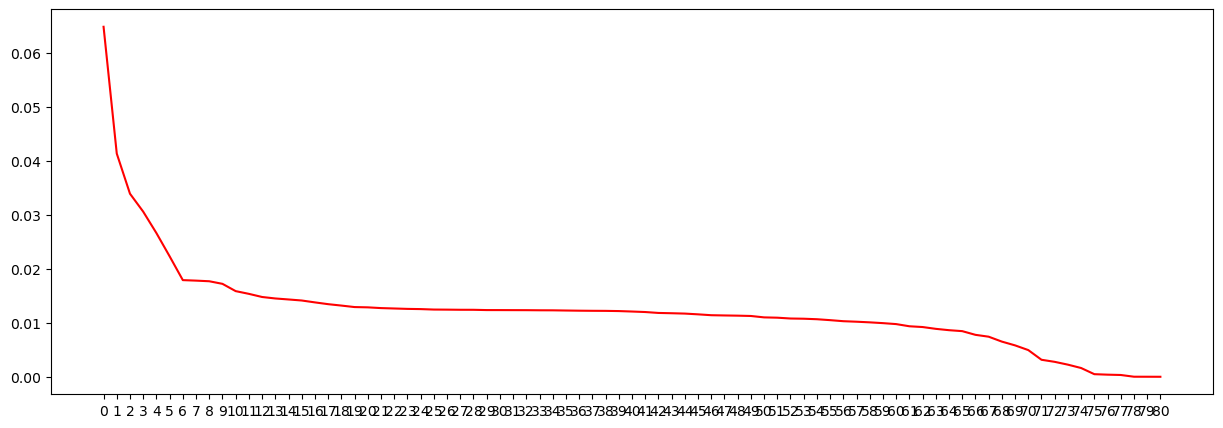

In [11]:
# A idéia agora é usar a técnica PCA para mais uma etapa de normalização dos atributos
pca = PCA(n_components=df_tratado_scaled.shape[1])
pca.fit(df_tratado_scaled)

#Técnica elbow para identificação do número ideal de componentes
plt.figure(figsize=(15, 5)) # criando um gráfico retangular para facilitar a visualização
plt.plot(pca.explained_variance_ratio_, color='r') # colocando a porcentagem de variância que cada componente nos trouxe
plt.xticks(np.arange(df_tratado_scaled.shape[1])) # mostrando todos os números no eixo x
plt.show() # mostrando o gráfico final

 # Com base no gráfico podemos identificar que o número ideal de componentes é 3.

In [12]:
# Aplicando PCA agora com apenas 3 componentes
pca = PCA(n_components=3)
df_final = pd.DataFrame(pca.fit_transform(df_tratado_scaled))
df_final.head()

,0,1,2
0,0.816194,-3.166276,-2.436835
1,0.689249,-2.841586,-2.301129
2,-1.149786,-2.145739,-2.142926
3,-1.633987,-2.695150,-1.432828
4,1.268718,-2.739015,-2.652253


# Etapa de seleção e treinamento do modelo
## Com base no meu target 'round_winner' por se tratar de um dado binário CT ou T, temos um problema de classificação binária

In [13]:
# Separando o dataset entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    df_final, y, test_size=0.25, random_state=42)

In [14]:
#Instanciando o RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train) 

df_test = X_test.copy()
df_test['round_winner_real'] = y_test.values
df_test['round_winner_predict'] = clf.predict(X_test)
df_test

,0,1,2,round_winner_real,round_winner_predict
58488,3.119640,1.623305,-1.387853,CT,CT
78799,2.188692,-1.579337,-1.022215,T,T
98815,-3.816523,1.761342,-1.023159,CT,T
30217,-3.926779,0.156739,0.411218,T,T
81053,2.451794,1.231575,0.564048,CT,CT
...,...,...,...,...,...
114442,1.121205,-0.019400,1.123652,CT,T
36361,1.339079,-0.541483,-1.707162,T,CT
12035,-3.284742,-0.030389,0.045228,T,T
50038,1.011217,-1.918202,2.241112,T,T


In [15]:
#Avaliar a acurácia do modelo nos dados de teste
clf.score(X_test, y_test)

0.7040392343845787

# Conclusões
## Com uma acurácia de aproximadamente 70.4% (0.7040), o RandomForestClassifier está fazendo previsões corretas em cerca de 70.4% das amostras de teste, pode se considerar um bom resultado dado a natureza dos dados (cs:go)